In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target


In [3]:
y = y.astype(int)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X[:10000], y[:10000], test_size=0.2, random_state=42
)


In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)


In [7]:
svm_rbf = SVC(kernel='rbf', gamma='scale')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)


In [8]:
print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))
print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_rbf))


Linear SVM Accuracy: 0.923
RBF SVM Accuracy: 0.938


In [9]:
print("Confusion Matrix (Linear):")
print(confusion_matrix(y_test, y_pred_linear))

print("Confusion Matrix (RBF):")
print(confusion_matrix(y_test, y_pred_rbf))


Confusion Matrix (Linear):
[[206   0   0   0   0   0   1   0   0   0]
 [  0 213   1   0   0   0   0   0   2   0]
 [  4   3 181   4   3   2   1   2   2   2]
 [  0   5   6 169   1   5   0   5   1   0]
 [  1   0   0   0 200   1   2   0   1   6]
 [  0   3   6  10   2 148   1   0   4   2]
 [  3   0   3   0   1   3 209   0   1   0]
 [  0   3   1   2   2   0   0 205   0   3]
 [  0   3   3   5   0   4   0   1 146   4]
 [  2   2   3   3   4   1   0   7   1 169]]
Confusion Matrix (RBF):
[[205   0   1   0   0   0   1   0   0   0]
 [  0 210   4   0   0   1   0   0   1   0]
 [  3   0 194   2   1   0   1   1   1   1]
 [  1   2   5 176   0   2   0   5   1   0]
 [  0   0   4   0 198   2   1   1   0   5]
 [  3   3   3   7   0 154   3   1   2   0]
 [  3   0   7   0   0   5 204   0   1   0]
 [  0   2   1   1   3   0   0 206   0   3]
 [  0   1   2   2   1   3   0   1 154   2]
 [  1   1   3   5   0   0   0   6   1 175]]


In [10]:
print("Classification Report (Linear):")
print(classification_report(y_test, y_pred_linear))

print("Classification Report (RBF):")
print(classification_report(y_test, y_pred_rbf))


Classification Report (Linear):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       207
           1       0.92      0.99      0.95       216
           2       0.89      0.89      0.89       204
           3       0.88      0.88      0.88       192
           4       0.94      0.95      0.94       211
           5       0.90      0.84      0.87       176
           6       0.98      0.95      0.96       220
           7       0.93      0.95      0.94       216
           8       0.92      0.88      0.90       166
           9       0.91      0.88      0.89       192

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000

Classification Report (RBF):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       207
           1       0.96      0.97      0.97       216
           2     

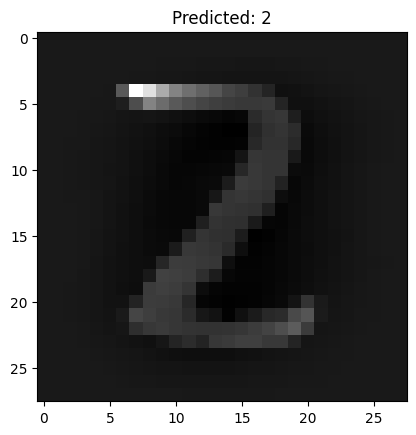

In [11]:
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {y_pred_rbf[0]}")
plt.show()
